# **Introducción a Inferencia estadística: prueba de Hipótesis por permutación**

## **Objetivo**
Introducir la prueba de permutación como alternativa intuitiva y basada en simulación a NHST ((prueba de significación de hipótesis nula).

## **¿Cómo funcionan realmente las pruebas de permutación?**

El propósito de una prueba de permutación es estimar la distribución de la población, la distribución de donde provienen nuestras observaciones. A partir de ahí, podemos determinar qué tan raros son nuestros valores observados en relación con la población.

 Un enfoque más robusto e intuitivo para NHST (prueba de significación de hipótesis nula) es reemplazar las distribuciones y tablas listas para usar con una simulación creada directamente a partir de  nuestro conjunto de datos.

## [**El flujo de trabajo**](https://i2.wp.com/rileyking.netlify.com/img/workflow.png?w=578&ssl=1)

La principal diferencia aquí es que creamos la distribución de los datos bajo la hipótesis nula usando simulación en lugar de confiar en una distribución de referencia. Es intuitivo, potente y divertido.

> ***Una hipótesis nula común para comparar grupos es que no hay diferencia entre ellos.***

1. mezclamos y asignamos aleatoriamente puntos de datos en dos grupos del tamaño original.

2. calculamos y almacenamos la estadística de prueba para el efecto observado (diferencia de medias entre los dos grupos)

3. vemos dónde se encuentran nuestros datos reales en relación con los simulados.


---


## [**Ejemplo:**](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3163409/)

```

# 14.1 comparación de dos medias ####

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3163409/"

# Imagine que acabamos de diseñar un experimento en el que tenemos
# la intención de medir la presión (en mm Hg) a la que un par
# de endoprótesis superpuestas comenzaron a migrar o
# desconectarse cuando se desplegaron en un gran *aneurisma torácico*.

https://www.google.com/search?q=aneurisma+tor%C3%A1cico&rlz=1C1CHBF_esPY990PY990&oq=aneurisma+tor%C3%A1cico&aqs=chrome..69i57j0i22i30l9.3520j0j4&sourceid=chrome&ie=UTF-8


#Migration pressure for predicate device
predicate <-  c(186, 188, 189, 189, 192, 193, 194, 194, 194,
                195, 195, 196, 196, 197, 197, 198, 198, 199, 199,
                201, 206, 207, 210, 213, 216, 218)

https://www.google.com/search?q=predicate+device+definition&rlz=1C1CHBF_esPY990PY990&oq=predicate+device&aqs=chrome.2.69i57j0i512l9.2606j0j4&sourceid=chrome&ie=UTF-8

#Migration pressure for next_gen device
next_gen <-  c(189, 190, 192, 193, 193, 196, 199,
               199, 199, 202, 203, 204, 205, 206, 206,
               207, 208, 208, 210, 210, 212, 214, 216, 216, 217, 218)

https://www.google.com/search?rlz=1C1CHBF_esPY990PY990&sxsrf=ALiCzsYgpkhOkNd0IAsSG-gLQhGRfknHUw:1666806289635&q=next+gen+device+definition&spell=1&sa=X&ved=2ahUKEwiM1rWmuf76AhXYqZUCHZwYAp0QBSgAegQICBAB&biw=1920&bih=872&dpr=1

```

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Configuración matplotlib
# ==============================================================================
style.use('ggplot') or plt.style.use('ggplot')

In [ ]:
## 1. Preparación (instalar e importar librerías)

# Instale paquetes si hace falta (descomente si usa Colab y no los tiene)
!pip install numpy pandas matplotlib seaborn scipy statsmodels

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Configuración gráfica
sns.set(style="whitegrid")
np.random.seed(2015)  # reproducibilidad conforme al script original


## 2. Datos y exploración (traducción literal de los vectoresy EDA)
# Migration pressure for predicate device
predicate = np.array([186, 188, 189, 189, 192, 193, 194, 194, 194,
                      195, 195, 196, 196, 197, 197, 198, 198, 199, 199,
                      201, 206, 207, 210, 213, 216, 218])

# Migration pressure for next_gen device
next_gen = np.array([189, 190, 192, 193, 193, 196, 199,
                     199, 199, 202, 203, 204, 205, 206, 206,
                     207, 208, 208, 210, 210, 212, 214, 216, 216, 217, 218])

# asigne cada grupo a una variable y conviértalo al formato tibble/DataFrame:
predicate_tbl = pd.DataFrame({"Device": "Predicate", "Pressure": predicate})
next_gen_tbl  = pd.DataFrame({"Device": "Next_Gen",  "Pressure": next_gen})

# Combine in DataFrame
results_tbl = pd.concat([predicate_tbl, next_gen_tbl], ignore_index=True)
results_tbl.head()

,Device,Pressure
0,Predicate,186
1,Predicate,188
2,Predicate,189
3,Predicate,189
4,Predicate,192


In [ ]:
#from google.colab import sheets
#sheet = sheets.InteractiveSheet(df=results_tbl)

Visualizaciones exploratorias

/tmp/ipython-input-751275559.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Device", y="Pressure", data=results_tbl,


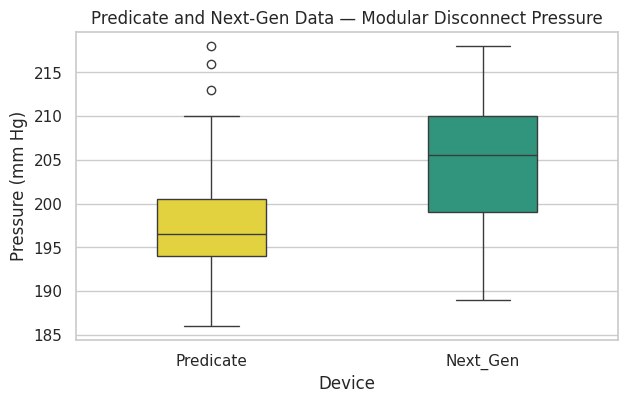

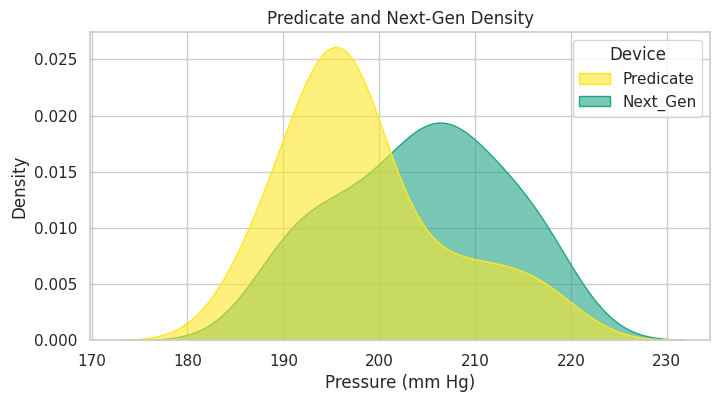

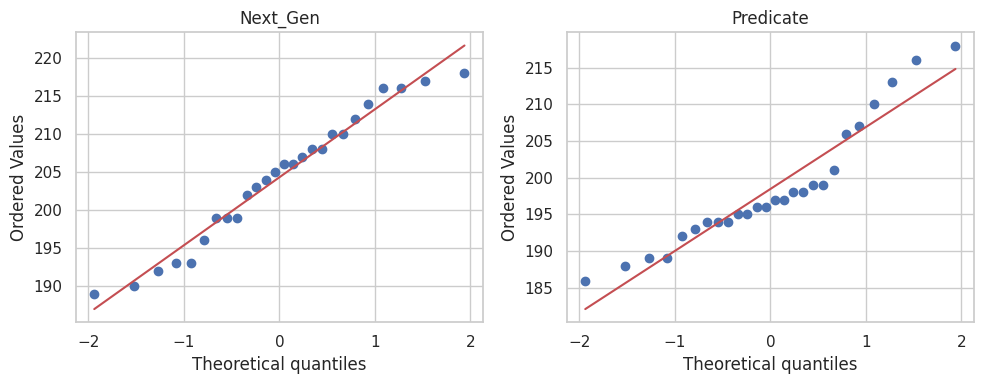

In [ ]:
# Boxplot
plt.figure(figsize=(7,4))
sns.boxplot(x="Device", y="Pressure", data=results_tbl,
            palette=["#FDE725", "#20A486"], width=.4)
plt.title("Predicate and Next-Gen Data — Modular Disconnect Pressure")
plt.ylabel("Pressure (mm Hg)")
plt.show()

# Density plot
plt.figure(figsize=(8,4))
sns.kdeplot(data=results_tbl, x="Pressure", hue="Device", fill=True,
            palette=["#FDE725", "#20A486"], alpha=0.6)
plt.title("Predicate and Next-Gen Density")
plt.xlabel("Pressure (mm Hg)")
plt.show()

# Q-Q plots por grupo
fig, axes = plt.subplots(1,2, figsize=(10,4))
for ax, (name, grp) in zip(axes, results_tbl.groupby("Device")):
    stats.probplot(grp["Pressure"], dist="norm", plot=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [ ]:
## 3. Prueba por permutación: función y simulación (traducción fiel)

# Función para intercambiar índices vectoriales y luego calcular
# la diferencia en las medias de los grupos
def permFun(x, n1, n2):
    """
    x: array con todas las observaciones concatenadas (orden no relevante)
    n1: tamaño del grupo B (se seleccionan n1 índices aleatorios)
    n2: tamaño del grupo A (resto)
    return: diferencia de medias (grupo_B - grupo_A)
    """
    n = n1 + n2
    group_B = np.random.choice(n, size=n1, replace=False)
    group_A = np.setdiff1d(np.arange(n), group_B)
    # mean(x[group_B] - mean(x[group_A])) en R equivale a mean(group_B) - mean(group_A)
    mean_diff = x[group_B].mean() - x[group_A].mean()
    return mean_diff

# Parámetros de la simulación
n_sims = 10000
x = results_tbl["Pressure"].values
n1 = (results_tbl["Device"] == "Predicate").sum()  # 26
n2 = (results_tbl["Device"] == "Next_Gen").sum()   # 26

# Inicializar vector de resultados
perm_diffs = np.zeros(n_sims)

# Iterar y almacenar (tal como en R)
for i in range(n_sims):
    perm_diffs[i] = permFun(x, n1, n2)

# Convertir a DataFrame para facilitar visualización posterior
perm_diffs_df = pd.DataFrame({"perm_diffs": perm_diffs})
perm_diffs_df.head()

,perm_diffs
0,-5.000000
1,2.384615
2,-2.076923
3,-2.692308
4,0.846154


Optimización opcional (vectorizada parcial): generar permutaciones muchas a la vez es no trivial por memoria; el bucle es aceptable para 10k repeticiones y es claro pedagógicamente.


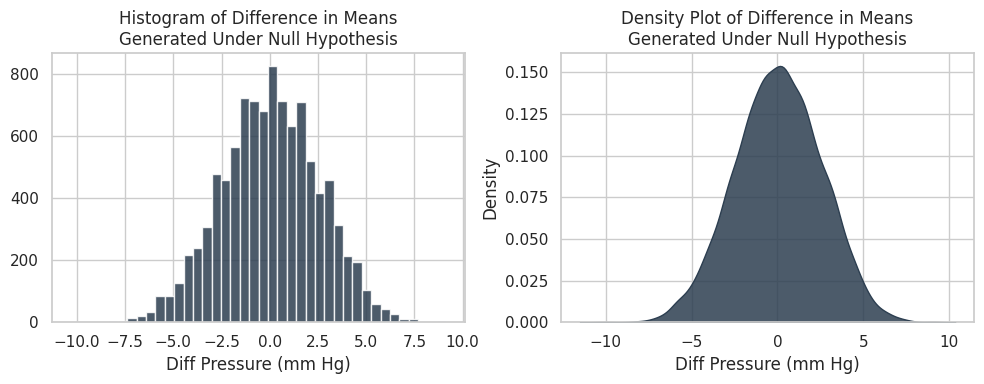

In [ ]:
## 4. Visualización de la distribución nula, estadística observada y p-valor

# Histograma y densidad de la distribución simulada bajo H0
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(perm_diffs, bins=40, color="#2c3e50", alpha=0.85)
plt.title("Histogram of Difference in Means\nGenerated Under Null Hypothesis")
plt.xlabel("Diff Pressure (mm Hg)")

plt.subplot(1,2,2)
sns.kdeplot(perm_diffs, fill=True, color="#2c3e50", alpha=0.85)
plt.title("Density Plot of Difference in Means\nGenerated Under Null Hypothesis")
plt.xlabel("Diff Pressure (mm Hg)")
plt.tight_layout()
plt.show()

Baseline difference (Predicate - Next_Gen): -5.846


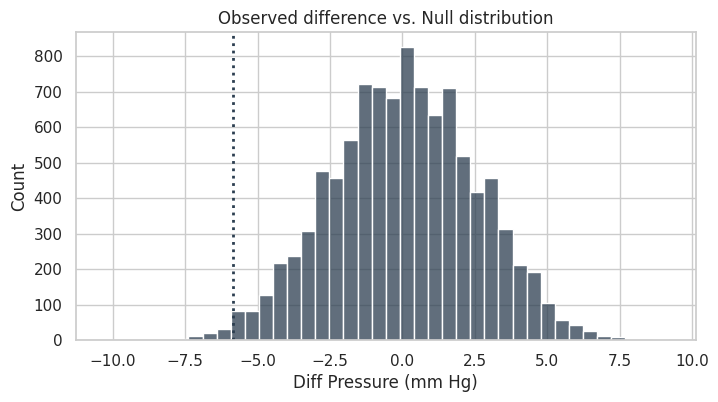

In [ ]:
# Calcular diferencia observada (baseline difference) en los datos reales
predicate_mean = predicate_tbl["Pressure"].mean()
next_gen_mean  = next_gen_tbl["Pressure"].mean()
baseline_difference = predicate_mean - next_gen_mean
print("Baseline difference (Predicate - Next_Gen):", round(baseline_difference, 3))

# Superponer la diferencia observada sobre la densidad/histograma
plt.figure(figsize=(8,4))
sns.histplot(perm_diffs, bins=40, color="#2c3e50", kde=False)
plt.axvline(baseline_difference, linestyle='dotted', color="#2c3e50", linewidth=2)
plt.title("Observed difference vs. Null distribution")
plt.xlabel("Diff Pressure (mm Hg)")
plt.show()

In [ ]:
# Calcular cuantil del 5% (unilateral izquierdo en el script R)
the_five_percent_quantile = np.quantile(perm_diffs, 0.05)
print("5% quantile (simulated):", the_five_percent_quantile)

# Empirical p-value (dirección según el script: perm_diffs <= baseline_difference)
p_value = np.mean(perm_diffs <= baseline_difference)
print("The empirical p-value is:", p_value)

5% quantile (simulated): -4.153846153846132
The empirical p-value is: 0.0102


In [ ]:
## Ejercicio 2: Comparación con pruebas paramétricas

# Realizar prueba t independiente (asume varianzas iguales)
ttest_independent = stats.ttest_ind(predicate, next_gen, equal_var=True)
print(f"Resultado de la prueba t independiente:")
print(f"  Estadístico t: {ttest_independent.statistic:.3f}")
print(f"  p-valor: {ttest_independent.pvalue:.4f}")

# Realizar prueba t de Welch (no asume varianzas iguales)
ttest_welch = stats.ttest_ind(predicate, next_gen, equal_var=False)
print(f"\nResultado de la prueba t de Welch:")
print(f"  Estadístico t: {ttest_welch.statistic:.3f}")
print(f"  p-valor: {ttest_welch.pvalue:.4f}")

# Calculate the empirical p-value from permutation test within this cell
baseline_difference = predicate.mean() - next_gen.mean()
p_value = np.mean(perm_diffs <= baseline_difference)


# Mostrar el p-valor de la permutación para comparación
print(f"\nEmpirical p-value from permutation test: {p_value:.4f}")

# Discusión (puede ser un markdown cell después)
# print("\nDiscusión:")
# print("- Compare los p-valores. ¿Son similares o diferentes?")
# print("- ¿Qué sugiere esto sobre las suposiciones de la prueba t en este caso?")
# print("- ¿Cuándo esperaríamos que los resultados coincidan y cuándo no?")

Resultado de la prueba t independiente:
  Estadístico t: -2.459
  p-valor: 0.0174

Resultado de la prueba t de Welch:
  Estadístico t: -2.459
  p-valor: 0.0174

Empirical p-value from permutation test: 0.0102


In [ ]:
# Optimización opcional (vectorizada parcial) - Original (has limitations for replace=False with multiple simulations)
def permFun_vectorized_original(x, n1, n2, n_sims):
    """
    x: array con todas las observaciones concatenadas
    n1: tamaño del grupo B
    n2: tamaño del grupo A
    n: tamaño total
    n_sims: número de simulaciones

    return: array de diferencias de medias (grupo_B - grupo_A) para n_sims permutaciones
    """
    n = n1 + n2
    # Generar índices aleatorios para el grupo B para todas las simulaciones
    # This original implementation can cause ValueError if n_sims * n1 > n when replace=False
    group_B_indices = np.random.choice(n, size=(n_sims, n1), replace=False)

    # Calcular las medias de los grupos A y B para cada simulación
    # Usamos advanced indexing para seleccionar los elementos de x
    mean_B = x[group_B_indices].mean(axis=1)

    # Los índices del grupo A son los que no están en group_B_indices
    # Esto es más complejo de vectorizar directamente en numpy para todas las simulaciones a la vez
    # Una alternativa es calcular la suma total y restar la suma de B
    total_sum = x.sum()
    sum_B = x[group_B_indices].sum(axis=1)
    sum_A = total_sum - sum_B
    mean_A = sum_A / n2

    # Calcular la diferencia de medias
    mean_diffs = mean_B - mean_A

    return mean_diffs

# Corrected vectorized permutation function
def permFun_vectorized(x, n1, n2, n_sims):
    """
    x: array con todas las observaciones concatenadas
    n1: tamaño del grupo B
    n2: tamaño del grupo A
    n: tamaño total
    n_sims: número de simulaciones

    return: array de diferencias de medias (grupo_B - grupo_A) para n_sims permutaciones
    """
    n = n1 + n2
    # Create an array of indices to shuffle
    indices = np.arange(n)
    # Shuffle the indices n_sims times
    # Using a list comprehension for shuffling each simulation independently
    shuffled_indices = np.array([np.random.permutation(indices) for _ in range(n_sims)])

    # Split the shuffled indices into two groups for each simulation
    group_B_indices = shuffled_indices[:, :n1]
    group_A_indices = shuffled_indices[:, n1:]

    # Calculate the means of the groups for each simulation
    mean_B = x[group_B_indices].mean(axis=1)
    mean_A = x[group_A_indices].mean(axis=1)

    # Calculate the difference of means
    mean_diffs = mean_B - mean_A

    return mean_diffs


# Ejemplo de uso (compare con el bucle anterior):
# n_sims_opt = 10000 # Puedes aumentar este número si la memoria lo permite
# perm_diffs_opt = permFun_vectorized(x, n1, n2, n_sims_opt)
# print(perm_diffs_opt[:5]) # Mostrar los primeros 5 resultados

Comparación de tiempos de computo permutaciones iterativas vs vectorizadas

Comparing computation times...
Running with n_sims = 100...
Running with n_sims = 1000...
Running with n_sims = 5000...
Running with n_sims = 10000...
Running with n_sims = 50000...


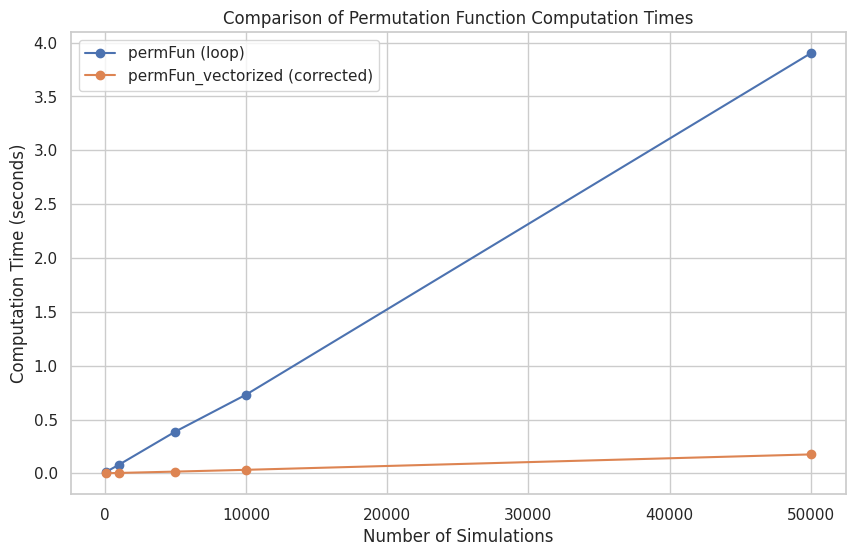

In [ ]:
import time
import matplotlib.pyplot as plt

# Define a range of simulation sizes to test
sim_sizes = [100, 1000, 5000, 10000, 50000] # You can adjust this range

# Lists to store computation times
time_permFun = []
time_permFun_vectorized = []

# Get the data and group sizes (assuming these are already defined)
# x = results_tbl["Pressure"].values
# n1 = (results_tbl["Device"] == "Predicate").sum()
# n2 = (results_tbl["Device"] == "Next_Gen").sum()

print("Comparing computation times...")

for n_sims in sim_sizes:
    print(f"Running with n_sims = {n_sims}...")

    # Time the original permFun (loop)
    start_time = time.time()
    perm_diffs_loop = np.zeros(n_sims)
    for i in range(n_sims):
        perm_diffs_loop[i] = permFun(x, n1, n2)
    end_time = time.time()
    time_permFun.append(end_time - start_time)

    # Time the corrected vectorized permFun_vectorized
    start_time = time.time()
    # Use the corrected vectorized function
    perm_diffs_vectorized = permFun_vectorized(x, n1, n2, n_sims)
    end_time = time.time()
    time_permFun_vectorized.append(end_time - start_time)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(sim_sizes, time_permFun, marker='o', label='permFun (loop)')
plt.plot(sim_sizes, time_permFun_vectorized, marker='o', label='permFun_vectorized (corrected)')
plt.xlabel("Number of Simulations")
plt.ylabel("Computation Time (seconds)")
plt.title("Comparison of Permutation Function Computation Times")
plt.legend()
plt.grid(True)
plt.show()


Comentarios:
- El script original usa una prueba unilaterial (cola izquierda) al computar proporción perm_diffs <= baseline_difference. Si la hipótesis alternativa es bilateral, use p = mean(|perm_diffs| >= |baseline_difference|).

---

## 5. **Formalización matemática breve (integrada en la actividad)**


**Formalización breve para la prueba de permutación**

La prueba de permutación se utiliza para evaluar la significancia de un estadístico de prueba obtenido a partir de los datos observados.

**Modelo**  
Se comparan muestras obtenidas de manera aleatoria, bajo la suposición nula de que las distribuciones de los grupos son similares.

**Hipótesis estadistica**  
H0: Las distribuciones son iguales.  
H1: Las distribuciones son diferentes.

**Estadístico de prueba**  
Se calcula un estadístico en cada permutación y se compara con el valor observado.

**Procedimiento de permutación**  
Permutar las observaciones entre los grupos y recalcular el estadístico.

**Valor p**  
Es la proporción de permutaciones más extremas que el valor observado.

**Dependencias**  
Asunción de intercambiabilidad entre las observaciones.

### Modelo y objetivo

Sea $X_{1},\dots,X_{n}$ el conjunto total de observaciones concatenadas de dos muestras originales (grupo A y grupo B) de tamaños $n_1$ y $n_2$ con $n=n_1+n_2$. El objetivo es probar
\begin{equation}
H_0:\ \text{las dos muestras provienen de la misma distribución (no hay efecto de grupo)}
\end{equation}
frente a una alternativa (unilateral o bilateral) sobre la diferencia de localización entre grupos.

---

### Estadística de interés

Defínase la media muestral de cada grupo en los datos observados:
\begin{equation}
\bar{X}_A=\frac{1}{n_1}\sum_{j\in A} X_j,\qquad
\bar{X}_B=\frac{1}{n_2}\sum_{j\in B} X_j.
\end{equation}
La estadística de prueba usada es la diferencia de medias observada
\begin{equation}
T_{\text{obs}}=\bar{X}_A-\bar{X}_B.
\end{equation}

---

### Procedimiento de permutación (construcción de la distribución nula)

Bajo $H_0$ las etiquetas de grupo son intercambiables (exchangeability). El procedimiento empírico crea la distribución nula de $T$ mediante:

1. Concatenar todas las observaciones en $x=(X_1,\dots,X_n)$.
2. Repetir $K$ veces (a.k.a. n_sims):
   - Seleccionar aleatoriamente un subconjunto $B_k\subset\{1,\dots,n\}$ de tamaño $n_1$ (o de tamaño del primer grupo), y definir $A_k=\{1,\dots,n\}\setminus B_k$.
   - Calcular la estadística de permutación
     \begin{equation}
     T^{(k)}=\frac{1}{|A_k|}\sum_{j\in A_k} x_j \;-\; \frac{1}{|B_k|}\sum_{j\in B_k} x_j.
     \end{equation}
3. Obtener la muestra empírica $\{T^{(1)},\dots,T^{(K)}\}$ que representa la distribución de $T$ bajo $H_0$.

---

### Cálculo del p-valor empírico

- Para una alternativa unilateral izquierda (señalada en el código original: valores pequeños indican efecto),
  \begin{equation}
  \hat p = \frac{1}{K}\sum_{k=1}^K \mathbf{1}\{T^{(k)} \le T_{\text{obs}}\}.
  \end{equation}
- Para alternativa unilateral derecha:
  \begin{equation}
  \hat p = \frac{1}{K}\sum_{k=1}^K \mathbf{1}\{T^{(k)} \ge T_{\text{obs}}\}.
  \end{equation}
- Para alternativa bilateral:
  \begin{equation}
  \hat p = \frac{1}{K}\sum_{k=1}^K \mathbf{1}\{|T^{(k)}| \ge |T_{\text{obs}}|\}.
  \end{equation}
Regla de decisión: rechazar $H_0$ al nivel $\alpha$ si $\hat p \le \alpha$.

---

### Supuestos y justificación

- Intercambiabilidad de las observaciones bajo $H_0$ es el supuesto esencial; no se requiere normalidad ni igualdad de varianzas.
- La validez exacta de la prueba es perfecta cuando se consideran todas las permutaciones posibles; con $K$ permutaciones aleatorias es una aproximación Monte Carlo con error $\mathcal{O}(1/\sqrt{K})$.
- La estadística puede adaptarse (medianas, diferencias de proporciones, medidas robustas) si interesa mayor robustez frente a outliers o colas pesadas.

---

### Propiedades prácticas

- Interpretación del p-valor empírico: proporción de permutaciones bajo $H_0$ que producen una estadística al menos tan extrema como la observada.
- Si $K$ es grande, $\hat p$ es una estimación consistente del p-valor exacto; para $K$ finito conviene reportar el numerador y denominador (por ejemplo, $r/K$).


---


### **Ejercicio**

Contexto breve (para el aula)  
   
   > Un equipo médico quiere comparar dos diseños de endoprótesis (Predicate vs Next_Gen) en la presión (mm Hg) a la que comienza la migración o desconexión. Tienen muestras experimentales de cada diseño (como en los scripts de clase). Formular claramente, por escrito, las cinco secciones solicitadas a continuación para este estudio y justificar brevemente cada decisión (1–2 frases cada una).


**Redacta**


   1. Pregunta de investigación (qué se quiere conocer)  


   2. Hipótesis de investigación (hipótesis cualitativa)  


   3. Predicción consecuente (qué observaríamos en los datos si la hipótesis de investigación fuera cierta)  


   4. Hipótesis estadística para verificar la predicción (formulación nula y alternativa)  


   5. Luego de leer el artículo en cuestión, menciona brevemente el diseño de estudio.

     

## 6. Ejercicios formativos

1. (Direccionalidad) Calcule el p-valor bilateral y compárelo con el p unilateral del script original; explique diferencias de interpretación.
2. (Estadística alternativa) Reemplace la media por la mediana como estadística de interés y repita la permutación; compare robustez frente a outliers.

Avanzado:

3. (Eficiencia) Implemente una versión que calcule permutaciones en paralelo (p.ej. con joblib) y compare tiempos con la versión secuencial.

---


### Ver

- https://sustainabilitymethods.org/index.php/Permutation_Test
- https://netneurotools.readthedocs.io/en/latest/auto_examples/plot_perm_pvals.html
- https://jrladd.com/CIS241/guides/hypothesis-testing.html
- https://rasbt.github.io/mlxtend/user_guide/evaluate/permutation_test/#example-1-two-sided-randomization-test
- https://www.geeksforgeeks.org/machine-learning/permutation-tests-in-machine-learning/
- https://github.com/qbarthelemy/PyPermut
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.permutation_test_score.html
- https://cienciadedatos.net/documentos/pystats03-test-permutacion-python

## **Paso a paso:**

### 📐 Estimación del valor p en pruebas de permutación

- **🔢 Paso 1: Seleccionar una estadística de prueba**
  - Elige una medida que represente la hipótesis a evaluar (ej. diferencia de medias, coeficiente de correlación, etc.).

- **🔀 Paso 2: Permutar los datos (simular la hipótesis nula)**
  - Bajo la hipótesis nula \( H_0 \), se asume que no hay diferencia ni asociación real.
  - Se reordenan los datos para eliminar cualquier estructura, manteniendo etiquetas o relaciones intactas.

- **📊 Paso 3: Construir la distribución nula**
  - Se generan múltiples permutaciones y se calcula la estadística de prueba en cada una.
  - Esto produce una distribución de referencia bajo \( H_0 \), que representa lo esperado por azar.

- **📉 Paso 4: Comparar con el valor observado y calcular el valor p**
  - Se compara la estadística original (sin permutación) con la distribución nula.
  - El valor p es la proporción de permutaciones con estadística igual o más extrema que la observada.

- **📌 Consideraciones según el tipo de prueba**
  - En pruebas **unilaterales**, se considera solo un extremo (mayor o menor).
  - En pruebas **bilaterales**, se consideran ambos extremos según la hipótesis planteada.



## 🧪 Actividad de simulación: Estimación del valor p con pruebas de permutación

### 🎯 Objetivo
Simular una prueba de hipótesis mediante permutaciones para estimar el valor p, sin asumir distribuciones específicas.

### 📦 Paso 0: Preparación del entorno

In [ ]:
# Instalación de dependencias (si es necesario)
!pip install numpy matplotlib

# Importación de librerías
import numpy as np
import matplotlib.pyplot as plt

### 🔢 Paso 1: Seleccionar una estadística de prueba

In [ ]:
# Simulación de dos grupos con diferencia de medias
np.random.seed(42)
grupo_A = np.random.normal(loc=5.0, scale=1.0, size=30)
grupo_B = np.random.normal(loc=6.0, scale=1.0, size=30)

# Estadística observada: diferencia de medias
observado = np.mean(grupo_B) - np.mean(grupo_A)
print(f"Diferencia observada de medias: {observado:.3f}")

Diferencia observada de medias: 1.067


### 🔀 Paso 2: Permutar los datos (simular H₀)

In [ ]:
# Combinar ambos grupos
datos_combinados = np.concatenate([grupo_A, grupo_B])
n_permutaciones = 1000000
estadisticas_nulas = []

# Generar distribución nula
for _ in range(n_permutaciones):
    np.random.shuffle(datos_combinados)
    perm_A = datos_combinados[:30]
    perm_B = datos_combinados[30:]
    estadistica = np.mean(perm_B) - np.mean(perm_A)
    estadisticas_nulas.append(estadistica)

### 📉 Paso 3: Calcular el valor p

In [ ]:
# Valor p unilateral (mayor o igual que observado)
valor_p = np.mean(np.array(estadisticas_nulas) >= observado)
print(f"Valor p estimado: {valor_p:.3f}")

Valor p estimado: 0.000


### 📊 Paso 4: Visualización de la distribución nula

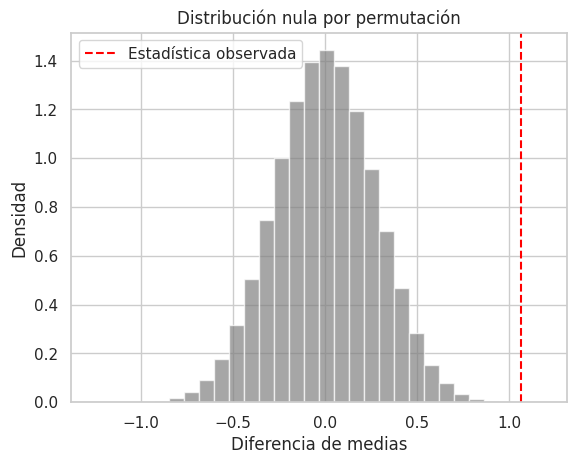

In [ ]:
plt.hist(estadisticas_nulas, bins=30, color="gray", alpha=0.7, density=True)
plt.axvline(observado, color="red", linestyle="--", label="Estadística observada")
plt.xlabel("Diferencia de medias")
plt.ylabel("Densidad")
plt.title("Distribución nula por permutación")
plt.legend()
plt.show()

### 🧠 Reflexión
- Esta actividad permite enseñar inferencia sin supuestos paramétricos.
- Puede adaptarse para comparar correlaciones, medianas, o cualquier estadística relevante.

### 📌 Interpretación de valores p en pruebas de permutación

- El **valor p** indica la probabilidad de obtener una estadística de prueba tan extrema como la observada, **bajo la hipótesis nula**.
- Un **valor p bajo** sugiere que el resultado observado **es poco probable por azar**, lo que proporciona evidencia contra la hipótesis nula.
- Para determinar si el resultado es **estadísticamente significativo**, se compara el valor p con un **nivel de significancia predefinido** (ej. $ \alpha = 0.05 $).
- Si el **valor p < \alpha**, se **rechaza la hipótesis nula** y se acepta la **hipótesis alternativa**, indicando una diferencia o efecto significativo.

---

### ✅ Beneficios de las pruebas de permutación

- **Flexibilidad**: Se pueden aplicar a distintos tipos de datos y estadísticas de prueba.
- **Pocos supuestos**: No requieren asumir distribuciones específicas en los datos.

---

### ⚠️ Limitaciones de las pruebas de permutación

- **Alto costo computacional**: Para conjuntos de datos grandes, calcular todas las permutaciones puede ser muy exigente.
- **Aplicabilidad restringida**: No son adecuadas para todos los tipos de pruebas de hipótesis.

---

### 🤖 Aplicaciones en aprendizaje automático

- Evaluar la **significancia de la importancia de variables** en modelos predictivos.
- Comparar el **rendimiento entre algoritmos o configuraciones** de modelos.
- Detectar **correlaciones entre variables** en conjuntos de datos.
- Validar la **efectividad de técnicas de preprocesamiento** o transformaciones de datos.

---



---

### 🧪 [**Ejemplo: Comparación de varianzas entre grupos**](https://cienciadedatos.net/documentos/pystats03-test-permutacion-python)

#### 📌 Contexto general
- En estudios comparativos, suele analizarse la **posición de las distribuciones** (media, mediana).
- Sin embargo, también puede ser relevante comparar **la dispersión** (varianza) entre grupos.

#### 🧰 Método propuesto
- Se utiliza un **test de permutación**.
- El **estadístico de interés** es la **varianza** de cada grupo.

#### 🎓 Aplicación al estudio de empatía
- No se detectan diferencias significativas en la **media de puntuaciones** de empatía entre grupos.
- Se plantea evaluar si existe **diferencia en las varianzas**.
- Esto es relevante porque, aunque no aumente la empatía promedio, las actividades o intervenciones podrían **reducir la variabilidad entre individuos**.

#### 📊 Hipótesis del contraste
- **Hipótesis nula (H₀):**  
  Las varianzas son iguales:  
  $
  \sigma^2_{\text{control}} = \sigma^2_{\text{tratamiento}} \quad \Rightarrow \quad \sigma^2_{\text{control}} - \sigma^2_{\text{tratamiento}} = 0
  $
- **Hipótesis alternativa (H₁):**  
  Las varianzas son distintas:  
  $
  \sigma^2_{\text{control}} \neq \sigma^2_{\text{tratamiento}} \quad \Rightarrow \quad \sigma^2_{\text{control}} - \sigma^2_{\text{tratamiento}} \neq 0
  $

---



---

## 📐 Formalización: Comparación de varianzas mediante test de permutación

### 🎯 Objetivo
Evaluar si existe una diferencia significativa en la **varianza de la capacidad empática** entre dos grupos (control vs tratamiento), utilizando un **test de permutación**.

---

### 🧾 Definiciones

- Sea $ X = \{x_1, x_2, \dots, x_n\} $ el conjunto de puntuaciones de empatía.
- Los sujetos están divididos en dos grupos:
  - Grupo **control**: $ X_C = \{x_{C1}, \dots, x_{Cn_C}\} $
  - Grupo **tratamiento**: $ X_T = \{x_{T1}, \dots, x_{Tn_T}\} $
- Tamaños muestrales:
  - $ n_C = 187 $, $ n_T = 169 $, $ n = n_C + n_T = 356 $

---

### 📊 Estadístico de interés

- Se define la diferencia de varianzas como:
 $
  D = \text{Var}(X_C) - \text{Var}(X_T)
 $

---

### 🧪 Hipótesis

- **Hipótesis nula (H₀):**  
  Las varianzas son iguales:  
  $
  \sigma^2_C = \sigma^2_T \quad \Rightarrow \quad D = 0
  $

- **Hipótesis alternativa (H₁):**  
  Las varianzas son distintas:  
  $
  \sigma^2_C \neq \sigma^2_T \quad \Rightarrow \quad D \neq 0
  $

---

### 🔁 Procedimiento de permutación

1. **Calcular $ D_{\text{obs}} $**: diferencia observada de varianzas entre grupos reales.
2. **Repetir $ B $ veces** (ej. $ B = 10{,}000 $):
   - Reorganizar aleatoriamente las etiquetas de grupo.
   - Calcular $ D_b $ para cada permutación.
3. **Estimar el p-valor** como:
   $
   p = \frac{1}{B} \sum_{b=1}^{B} \mathbb{I}(|D_b| \geq |D_{\text{obs}}|)
   $
   donde $ \mathbb{I} $ es la función indicadora.

---

### ⚠️ Consideraciones metodológicas

- Se aplica **corrección de continuidad** según Davison & Hinkley (1997).
- La asignación a grupos fue aleatoria, pero **la selección de sujetos no lo fue**, por lo que **no se puede extrapolar** a la población general.

---





---

### 📐 Corrección de continuidad según Davison & Hinkley (1997)

La **corrección de continuidad** es una técnica utilizada en el contexto de **tests de permutación** y **bootstrap** para mejorar la estimación del **p-valor** cuando el número de permutaciones es finito y discreto.

#### ⚙️ Propósito
- Ajustar la estimación del p-valor para evitar que sea exactamente 0 o 1.
- Mejorar la aproximación a la distribución teórica del estadístico bajo la hipótesis nula.
- Evitar decisiones extremas en pruebas con pocos reordenamientos posibles.

#### 📊 Fórmula ajustada
Si se realizan $ B $ permutaciones y se observa $ b $ casos en los que el estadístico permutado es tan extremo como el observado, el p-valor corregido se calcula como:

$
p = \frac{b + 1}{B + 1}
$

#### 📚 Referencia
Este ajuste fue propuesto por **Davison & Hinkley (1997)** en su obra *Bootstrap Methods and Their Application*, como una forma robusta de evitar errores tipo I o II por estimaciones límite en pruebas no paramétricas.

---


### En primer lugar, se calcula la diferencia entre las varianzas de ambos grupos (diferencia observada).

In [ ]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Configuración matplotlib
# ==============================================================================
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

# Varios
# ==============================================================================
from tqdm import tqdm

### **Datos**



In [ ]:
# Datos
# ==============================================================================
url = 'https://raw.githubusercontent.com/JoaquinAmatRodrigo/Estadistica-con-R/' \
      + 'master/datos/AfterSchool.csv'
datos = pd.read_csv(url)
datos = datos[['Treatment', 'Delinq']]
datos = datos.rename(columns={'Treatment': 'grupo', 'Delinq': 'valor'})
datos['grupo'] = np.where(datos['grupo'] == 0, 'control', 'tratamiento')
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   grupo   356 non-null    object 
 1   valor   356 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.7+ KB


### **Análisis descriptivo**

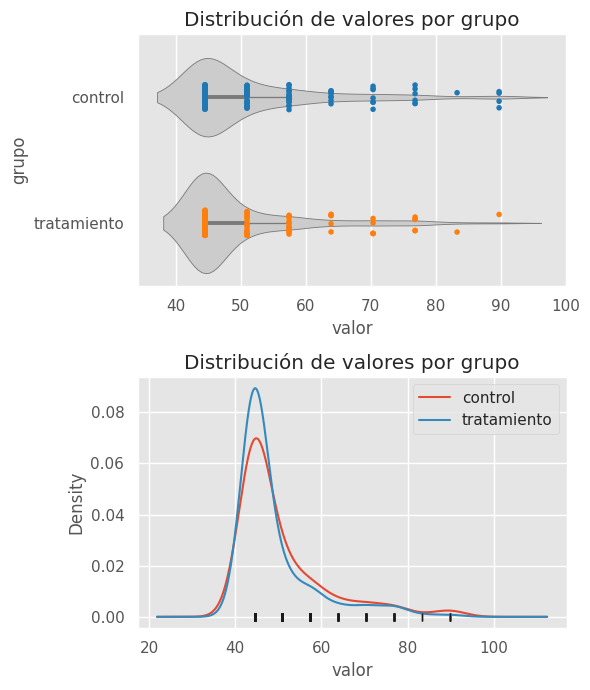

In [ ]:
# Gráficos distribución observada
# ==============================================================================
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 7))
sns.violinplot(
    x     = datos.valor,
    y     = datos.grupo,
    color = ".8",
    ax    = axs[0]
)
sns.stripplot(
    x    = datos.valor,
    y    = datos.grupo,
    data = datos,
    size = 4,
    jitter  = 0.1,
    palette = 'tab10',
    ax = axs[0]
)
axs[0].set_title('Distribución de valores por grupo')
axs[0].set_ylabel('grupo')
axs[0].set_xlabel('valor');

for grupo in datos.grupo.unique():
    datos_temp = datos[datos.grupo == grupo]['valor']
    datos_temp.plot.kde(ax=axs[1], label=grupo)
    axs[1].plot(datos_temp, np.full_like(datos_temp, 0), '|k', markeredgewidth=1)

axs[1].set_title('Distribución de valores por grupo')
axs[1].set_xlabel('valor');
axs[1].legend()

fig.tight_layout();

In [ ]:
# Estadísticos descriptivos por grupo
# ==============================================================================
datos.groupby(by='grupo').describe()

valor                                                        \
             count       mean       std        min        25%        50%   
grupo                                                                      
control      187.0  50.725591  10.52089  44.463082  44.463082  44.463082   
tratamiento  169.0  49.018956   8.97423  44.463082  44.463082  44.463082   

                                   
                   75%        max  
grupo                              
control      50.933188  89.753823  
tratamiento  50.933188  89.753823

In [ ]:
def dif_var(x1, x2):
    '''
    Función para calcular la diferencia de varianzas entre dos muestras.

    Parameters
    ----------
    x1 : numpy array
         valores de la muestra 1.

    x2 : numpy array
         valores de la muestra 2.

    Returns
    -------
    estadístico: float
        valor del estadístico.
    '''

    estadistico = np.var(x1) - np.var(x2)
    return(estadistico)

In [ ]:
dif_observada = dif_var(
                    x1 = datos[datos.grupo == 'control']['valor'],
                    x2 = datos[datos.grupo == 'tratamiento']['valor']
                )
print(f"Diferencia observada: {dif_observada}")

Diferencia observada: 30.036953280863898


Mediante permutaciones, se obtiene la distribución de la diferencia de varianza esperada debida únicamente al reparto aleatorio de los grupos, siendo cierta la hipótesis nula.

Para obtener la probabilidad exacta, se necesita generar todas las posibles combinaciones en las que, 356 sujetos, pueden repartirse en dos grupos de 187 y 169, y calcular la diferencia de varianza para cada una. El número de combinaciones posibles es muy elevado, ( 3.93x10105), por lo que no es factible calcularlas todas. En su lugar, se recurre a la **simulación de Monte Carlo**.

In [ ]:
def permutaciones(x1, x2, fun_estadistico, n_iteraciones=9999):
    '''
    Función para calcular el valor del estadístico en múltiples permutaciones
    de dos muestras.

    Parameters
    ----------
    x1 : numpy array
         valores de la muestra 1.

    x2 : numpy array
         valores de la muestra 2.

    fun_estadistico : function
        función que recibe como argumento las dos muestras y devuelve el valor
        del estadístico.

    n_iteraciones : int
        número de permutaciones calculadas (default `9999`).

    Returns
    -------
    distribuciones: numpy array
        valor del estadístico en cada permutación.
    '''

    n_x1 = len(x1)
    n_x2 = len(x2)
    pool_datos = np.hstack((x1, x2))

    resulados_permutaciones = np.full(shape=n_iteraciones, fill_value=np.nan)

    for i in tqdm(range(n_iteraciones)):
        np.random.shuffle(pool_datos)
        estadistico = fun_estadistico(pool_datos[:n_x1], pool_datos[n_x1:])
        resulados_permutaciones[i] = estadistico

    return resulados_permutaciones

In [ ]:
dist_permut = permutaciones(
                x1 = datos[datos.grupo == 'control']['valor'],
                x2 = datos[datos.grupo == 'tratamiento']['valor'],
                fun_estadistico = dif_var,
                n_iteraciones   = 9999
              )

100%|██████████| 9999/9999 [00:00<00:00, 27002.83it/s]


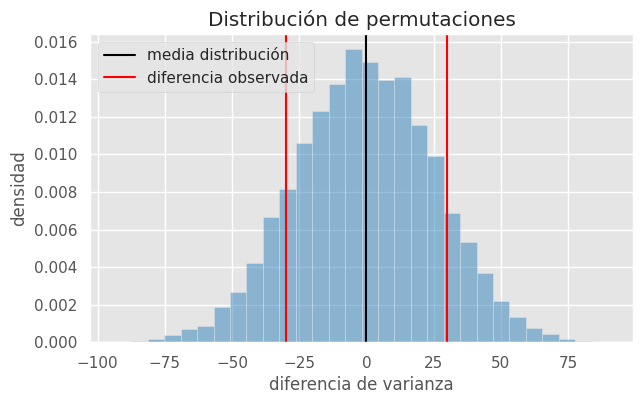

In [ ]:
# Distribución de permutaciones
# ==============================================================================
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(7,4))
ax.hist(dist_permut, bins=30, density=True, color='#3182bd', alpha=0.5)
ax.axvline(x=dist_permut.mean(), color='black', label='media distribución')
ax.axvline(x=dif_observada, color='red', label='diferencia observada')
ax.axvline(x=-dif_observada, color='red')

ax.set_title('Distribución de permutaciones')
ax.set_xlabel('diferencia de varianza')
ax.set_ylabel('densidad')
ax.legend();

La distribución de las permutaciones muestra que, la diferencia media entre varianzas si las actividades extra escolares no tiene efecto, es muy próxima a cero ( ∼0.05
 , línea vertical negra).

Finalmente, se calcula la probabilidad (p-value) de obtener diferencias iguales o más extremas que la observada (líneas verticales rojas) con y sin corrección de continuidad.

In [ ]:
# P-value empírico con y sin corrección
# ==============================================================================
p_value = (sum(np.abs(dist_permut) > np.abs(dif_observada)))/len(dist_permut)
p_value_correc = (sum(np.abs(dist_permut) > np.abs(dif_observada)) + 1)/len(dist_permut + 1)
print(f"p-value sin corrección: {p_value}")
print(f"p-value con corrección: {p_value_correc}")

p-value sin corrección: 0.24552455245524551
p-value con corrección: 0.24562456245624562


---

### 🧪 Resumen en ítems: Evaluación de varianza en capacidad empática

#### 📋 Diseño del estudio
- **Total de sujetos:** 356 estudiantes.
- **Asignación aleatoria a grupos:**
  - Grupo **control** (n = 187): no asistió a clases de repaso.
  - Grupo **tratamiento** (n = 169): asistió a clases de repaso.

#### 🧰 Método estadístico
- Se aplicó un **test de permutación** para comparar la **varianza** de la capacidad empática entre grupos.
- El **p-valor** fue estimado mediante **simulación de Monte Carlo**.
- Se utilizó la **corrección de continuidad** propuesta por **Davison & Hinkley (1997)**.

#### 📊 Resultados e interpretación
- El p-valor indica **evidencia muy débil** contra la hipótesis nula.
- No se puede afirmar que el tratamiento **modifique la variabilidad** en la capacidad empática.
- **Conclusión:** No hay evidencia estadística suficiente para sostener que asistir a clases extraescolares afecta la dispersión de la empatía.

---


# [**Pruebas de permutación para estudiar el rendimiento del clasificador**](https://www.jmlr.org/papers/volume11/ojala10a/ojala10a.pdf)


Este ejemplo demuestra el uso de permutation_test_scorepara evaluar la significancia de una puntuación de validación cruzada usando permutaciones.


```
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

```





### 🧪 Resumen del enfoque de valores p por permutación

- Se analiza el uso de **valores p basados en permutaciones** para evaluar el rendimiento de clasificadores.
- El estudio se centra en **dos pruebas de permutación simples**.
- La **primera prueba** evalúa si el clasificador ha identificado una **estructura real de clases** en los datos.
- Para ello, se estima la **distribución nula** mediante la **permutación aleatoria de las etiquetas** del conjunto de datos.
- Esta distribución permite contrastar la hipótesis nula de que **no existe relación entre características y clases**.


## **Conjunto de datos**

Utilizaremos el conjunto de datos de plantas de iris , que consta de mediciones tomadas de 3 especies de iris. Nuestro modelo utilizará las mediciones para predecir las especies de iris.

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

Para comparar, también generamos algunos datos de características aleatorios (es decir, 20 características), no correlacionados con las etiquetas de clase en el conjunto de datos de iris

In [ ]:
import numpy as np

n_uncorrelated_features = 20
rng = np.random.RandomState(seed=0)
# Use same number of samples as in iris and 20 features
X_rand = rng.normal(size=(X.shape[0], n_uncorrelated_features))

## **Permutation test score**

### 🧪 Resumen de la prueba de permutación con `permutation_test_score`

- Se aplica `permutation_test_score` a dos conjuntos de datos:
  - El conjunto original de iris (con fuerte relación entre características y etiquetas).
  - Un conjunto con características aleatorias y etiquetas de iris (sin dependencia esperada).

- Se utiliza el clasificador **SVC** y la **exactitud** como métrica de evaluación en cada ronda.

- El método genera una **distribución nula**:
  - Se realizan **1000 permutaciones** del conjunto de datos.
  - Las características se mantienen fijas.
  - Las etiquetas se permutan aleatoriamente.

- Esta distribución representa la **hipótesis nula**: no hay relación entre características y etiquetas.

- Se calcula un **valor p empírico**:
  - Es la proporción de permutaciones en las que la puntuación del modelo es **mayor o igual** a la obtenida con los datos originales.



In [ ]:
from sklearn.model_selection import StratifiedKFold, permutation_test_score
from sklearn.svm import SVC

clf = SVC(kernel="linear", random_state=7)
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=0)

score_iris, perm_scores_iris, pvalue_iris = permutation_test_score(
    clf, X, y, scoring="accuracy", cv=cv, n_permutations=1000
)

score_rand, perm_scores_rand, pvalue_rand = permutation_test_score(
    clf, X_rand, y, scoring="accuracy", cv=cv, n_permutations=1000
)

## **Datos originales**

### 📊 Interpretación del histograma de puntuaciones de permutación

- Se traza un **histograma** de las puntuaciones obtenidas por el clasificador en 1000 permutaciones (distribución nula).
- Una **línea roja** indica la puntuación del modelo entrenado con los datos originales (sin permutar etiquetas).
- La puntuación original es **significativamente superior** a las obtenidas con etiquetas permutadas.
- El **valor p es muy bajo**, lo que indica que es poco probable obtener esa puntuación por azar.
- Esto proporciona **evidencia estadística** de que existe una **dependencia real** entre características y etiquetas en el conjunto de datos de iris.
- El clasificador **aprovechó esa dependencia** para lograr buenos resultados.
- El bajo valor p permite **rechazar la hipótesis nula** de independencia entre variables.



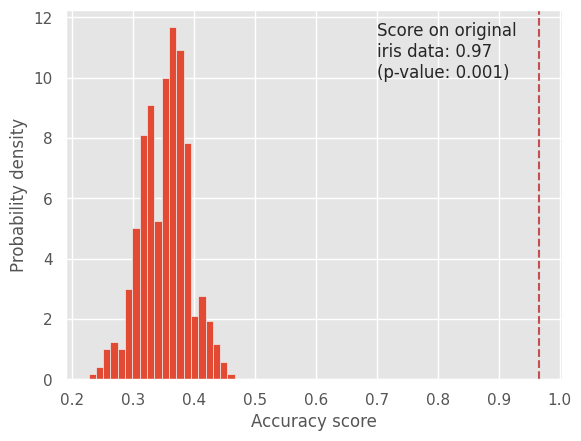

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.hist(perm_scores_iris, bins=20, density=True)
ax.axvline(score_iris, ls="--", color="r")
score_label = (
    f"Score on original\niris data: {score_iris:.2f}\n(p-value: {pvalue_iris:.3f})"
)
ax.text(0.7, 10, score_label, fontsize=12)
ax.set_xlabel("Accuracy score")
_ = ax.set_ylabel("Probability density")

## **Datos aleatorios**

### 🎲 Interpretación de la distribución nula con datos aleatorizados

- Se traza la **distribución nula** utilizando datos con características generadas aleatoriamente.
- Las **puntuaciones de permutación** son similares a las del conjunto original, ya que la permutación elimina cualquier dependencia entre características y etiquetas.
- La **puntuación del modelo** con datos aleatorizados es **muy baja**, indicando que no logra aprender patrones útiles.
- Esto genera un **valor p alto**, lo que sugiere que la puntuación obtenida podría surgir fácilmente por azar.
- Se **confirma la ausencia de dependencia** entre características y etiquetas en los datos aleatorizados.
- El resultado **valida la hipótesis nula**, mostrando que el modelo no puede extraer información significativa de datos sin estructura.

¿Te gustaría que lo incorpore como sección complementaria en la guía de Colab o que lo acompañe con una visualización reproducible?


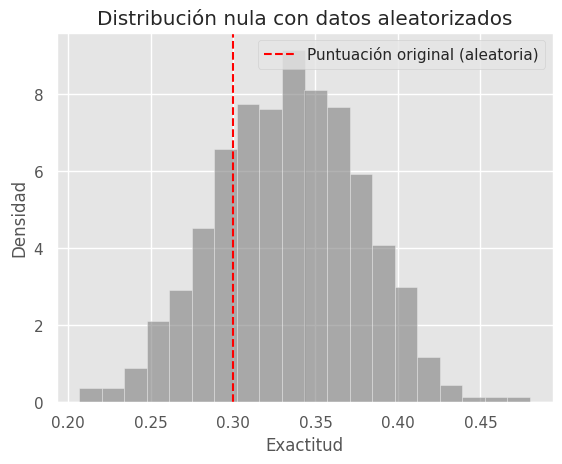

In [ ]:
import matplotlib.pyplot as plt

# Histograma de puntuaciones de permutación con datos aleatorizados
plt.hist(perm_scores_rand, bins=20, density=True, alpha=0.6, color="gray")
plt.axvline(score_rand, color="red", linestyle="--", label="Puntuación original (aleatoria)")
plt.xlabel("Exactitud")
plt.ylabel("Densidad")
plt.title("Distribución nula con datos aleatorizados")
plt.legend()
plt.show()

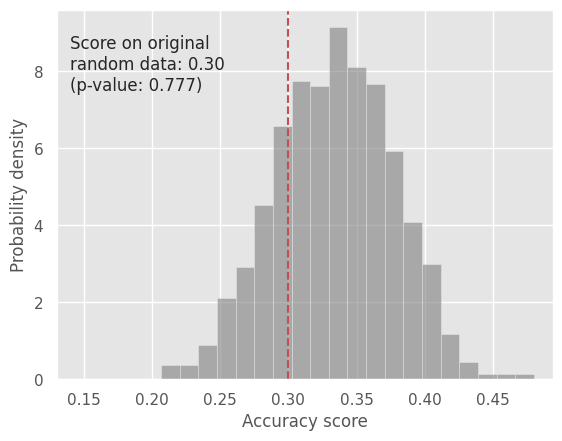

In [ ]:
fig, ax = plt.subplots()

ax.hist(perm_scores_rand, bins=20, density=True, alpha=0.6, color="gray")
ax.set_xlim(0.13)
ax.axvline(score_rand, ls="--", color="r")
score_label = (
    f"Score on original\nrandom data: {score_rand:.2f}\n(p-value: {pvalue_rand:.3f})"
)
ax.text(0.14, 7.5, score_label, fontsize=12)
ax.set_xlabel("Accuracy score")
ax.set_ylabel("Probability density")
plt.show()

Otra posible razón para obtener un valor p alto podría ser que el clasificador no pudo usar la estructura de los datos. En este caso, el valor p solo sería bajo para los clasificadores que pueden utilizar la dependencia presente. En nuestro caso anterior, donde los datos son aleatorios, todos los clasificadores tendrían un valor p alto, ya que no hay estructura presente en los datos. Podríamos o no fallar en rechazar la hipótesis nula dependiendo de si el valor p también es alto en un estimador más apropiado.

Finalmente, tenga en cuenta que se ha demostrado que esta prueba produce valores p bajos incluso si solo hay una estructura débil en los datos


---

### 🧪 [PERMANOVA](https://onlinelibrary.wiley.com/doi/full/10.1002/9781118445112.stat07841): Prueba de diferencias significativas entre grupos

#### 📌 Concepto general
- **PERMANOVA** (Permutational Multivariate Analysis of Variance) es una prueba **no paramétrica** para comparar grupos según una **variable categórica**.
- Similar a **ANOVA**, pero opera sobre **matrices de distancia** entre objetos, permitiendo análisis multivariado.
- A diferencia de **MANOVA**, no requiere supuestos sobre la distribución de los datos.

---

#### 📊 Estadística pseudo-F

- Se calcula como el **cociente entre la varianza entre grupos y la varianza dentro de los grupos**.
- Se basa en **sumas de cuadrados** divididas por sus respectivos **grados de libertad**.
- Es una versión análoga al estadístico F clásico, pero adaptada a contextos no paramétricos.

---

#### 🔀 Evaluación de significancia

- Se realiza mediante una **prueba de permutación**:
  - Se asignan los objetos a grupos según la variable categórica.
  - Se generan múltiples permutaciones de estas asignaciones.
  - Se calcula el **pseudo-F** para cada permutación.
- Bajo la **hipótesis nula**, los pseudo-F permutados deben seguir una distribución similar.
- El **valor p** se estima como la proporción de pseudo-F permutados **mayores o iguales** al pseudo-F observado.

---

![texto del enlace](https://archetypalecology.wordpress.com/wp-content/uploads/2018/02/screen-shot-2018-02-20-at-16-44-50.png?w=351&h=356)

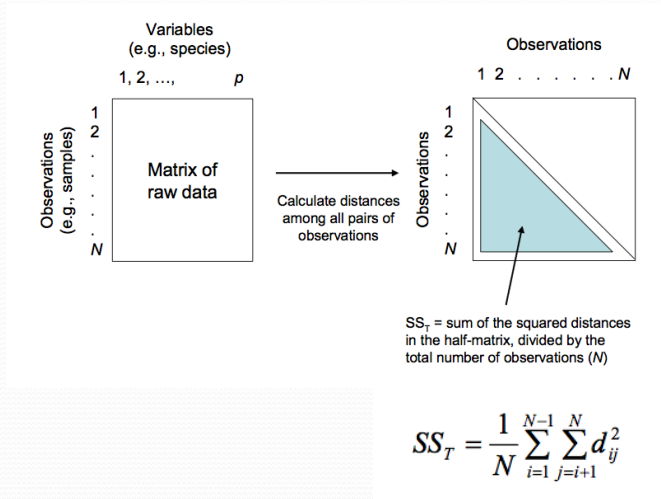

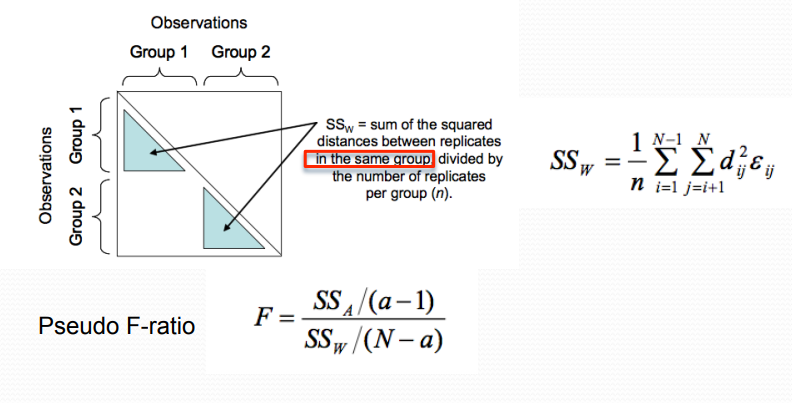

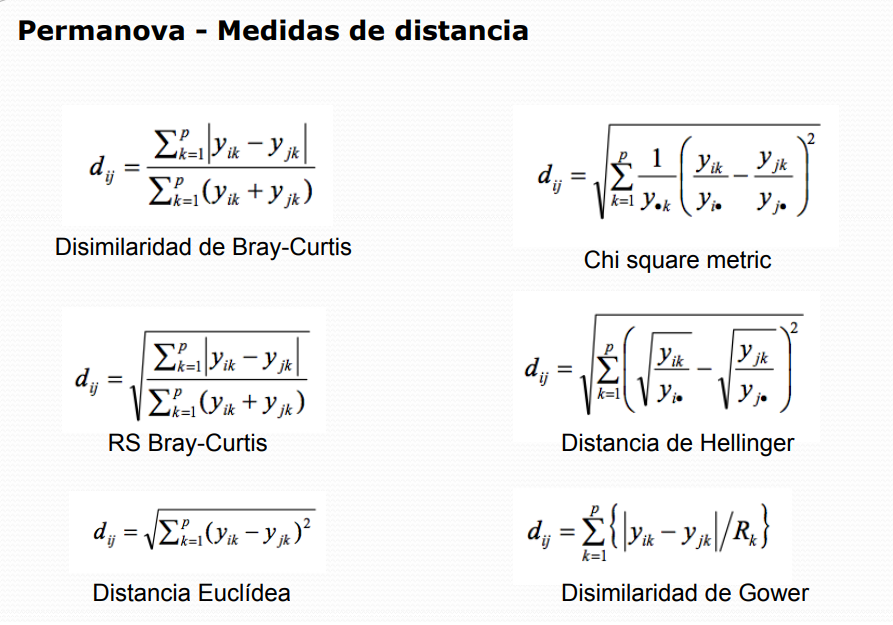

## 🧪 Actividad de simulación: PERMANOVA con permutaciones

### 🎯 Objetivo
Evaluar si existen diferencias significativas entre grupos categóricos en datos multivariados, sin asumir distribuciones específicas.

### 📦 Paso 0: Preparación del entorno

In [ ]:
# Instalación de dependencias
!pip install scikit-bio pandas numpy

# Importación de librerías
import numpy as np
import pandas as pd
from skbio.stats.distance import DistanceMatrix
from skbio.stats.distance import permanova
from skbio.stats.ordination import pcoa

### 🔢 Paso 1: Simulación de datos multivariados

In [ ]:
# Simulación de 3 grupos con 5 muestras cada uno y 4 variables
np.random.seed(42)
grupo_1 = np.random.normal(loc=5, scale=1, size=(5, 4))
grupo_2 = np.random.normal(loc=6, scale=1, size=(5, 4))
grupo_3 = np.random.normal(loc=7, scale=1, size=(5, 4))

# Concatenar datos y crear etiquetas
datos = np.vstack([grupo_1, grupo_2, grupo_3])
etiquetas = ['A']*5 + ['B']*5 + ['C']*5
df = pd.DataFrame(datos, columns=[f'Var{i+1}' for i in range(4)])
etiquetas, df

(['A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'C', 'C', 'C', 'C', 'C'],
         Var1      Var2      Var3      Var4
 0   5.496714  4.861736  5.647689  6.523030
 1   4.765847  4.765863  6.579213  5.767435
 2   4.530526  5.542560  4.536582  4.534270
 3   5.241962  3.086720  3.275082  4.437712
 4   3.987169  5.314247  4.091976  3.587696
 5   7.465649  5.774224  6.067528  4.575252
 6   5.455617  6.110923  4.849006  6.375698
 7   5.399361  5.708306  5.398293  7.852278
 8   5.986503  4.942289  6.822545  4.779156
 9   6.208864  4.040330  4.671814  6.196861
 10  7.738467  7.171368  6.884352  6.698896
 11  5.521478  6.280156  6.539361  8.057122
 12  7.343618  5.236960  7.324084  6.614918
 13  6.323078  7.611676  8.031000  7.931280
 14  6.160782  6.690788  7.331263  7.975545)

### 📊 Paso 2: Cálculo de matriz de distancias

In [ ]:
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix

# Matriz de distancias euclidianas
distancias = squareform(pdist(df.values, metric='euclidean'))
dm = DistanceMatrix(distancias)
dm

### 🧪 Paso 3: Aplicación de PERMANOVA

In [ ]:
# Aplicar PERMANOVA con 999 permutaciones
# The permanova function expects a DataFrame with a named column for grouping
# pd.Series(etiquetas, name='Group') creates a Series with the name 'Group'
# To fix the error, we need to ensure the DistanceMatrix has the same IDs as the grouping DataFrame
grouping_df = pd.DataFrame({'Group': etiquetas}, index=df.index)
dm = DistanceMatrix(distancias, ids=grouping_df.index)

resultado = permanova(dm, grouping_df, column='Group', permutations=999)
print(resultado)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      15
number of groups                  3
test statistic             6.768348
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


---

## 📐 Formalización matemática de PERMANOVA

### 1. **Contexto del problema**

Dado un conjunto de $ N $ objetos multivariados agrupados en $ G $ grupos definidos por una variable categórica, se desea evaluar si las diferencias entre grupos son estadísticamente significativas en función de una matriz de distancias $ D \in \mathbb{R}^{N \times N} $.

---

### 2. **Construcción de la matriz de distancias**

Sea $ \mathbf{x}_i \in \mathbb{R}^p $ el vector de características del objeto $ i $, y $ d_{ij} = \text{dist}(\mathbf{x}_i, \mathbf{x}_j) $ la distancia entre objetos $ i $ y $ j $, típicamente euclidiana:

$
d_{ij} = \sqrt{\sum_{k=1}^{p} (x_{ik} - x_{jk})^2}
$

---

### 3. **Descomposición de la suma de cuadrados**

Se define la suma total de cuadrados (SST), la suma entre grupos (SSB) y la suma dentro de grupos (SSW) sobre la matriz de distancias:

- **Suma total de cuadrados**:
$
SS_T = \frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{N} d_{ij}^2
$

- **Suma entre grupos**:
$
SS_B = \sum_{g=1}^{G} \frac{1}{n_g} \sum_{i,j \in g} d_{ij}^2
$

- **Suma dentro de grupos**:
$
SS_W = SS_T - SS_B
$

donde $ n_g $ es el número de objetos en el grupo $ g $.

---

### 4. **Estadístico pseudo-F**

Se define el estadístico pseudo-F como:

$
F^* = \frac{SS_B / (G - 1)}{SS_W / (N - G)}
$

Este estadístico mide la proporción de varianza explicada por la agrupación frente a la varianza residual.

---

### 5. **Evaluación por permutación**

- Se generan $ P $ permutaciones aleatorias de las asignaciones de grupo.
- Para cada permutación $ p $, se calcula $ F^*_p $.
- El valor p empírico se estima como:

$
p\text{-valor} = \frac{1}{P} \sum_{p=1}^{P} \mathbb{I}(F^*_p \geq F^*_{\text{obs}})
$

donde $ \mathbb{I} $ es la función indicadora y $ F^*_{\text{obs}} $ es el pseudo-F observado.

---

### 6. **Interpretación**

- Si $ p\text{-valor} < \alpha $, se rechaza la hipótesis nula: existe evidencia de diferencias significativas entre grupos.
- Si $ p\text{-valor} \geq \alpha $, no se rechaza la hipótesis nula: las diferencias pueden explicarse por azar.

---


---

## 📏 Medidas de distancia en análisis multivariado

### 1. **Distancia Euclidiana (L2)**

- **Fórmula**:  
  $
  d(x, y) = \sqrt{\sum_{i=1}^{p} (x_i - y_i)^2}
  $
- **Propiedades**: Métrica clásica; sensible a la escala de las variables.
- **Aplicaciones**: Clustering, PCA, PERMANOVA, análisis de conglomerados.

---

### 2. **Distancia de Manhattan (L1)**

- **Fórmula**:  
  $
  d(x, y) = \sum_{i=1}^{p} |x_i - y_i|
  $
- **Propiedades**: Más robusta a valores atípicos que la euclidiana.
- **Aplicaciones**: Modelos de redes, análisis de trayectorias, datos dispersos.

---

### 3. **Distancia de Mahalanobis**

- **Fórmula**:  
  $
  d(x, y) = \sqrt{(x - y)^T S^{-1} (x - y)}
  $
  donde $ S $ es la matriz de covarianza.
- **Propiedades**: Considera la correlación entre variables; invariante a escalas y rotaciones.
- **Aplicaciones**: Detección de valores atípicos, clasificación multivariada.

---

### 4. **Distancia de Bray-Curtis**

- **Fórmula**:  
  $
  d(x, y) = \frac{\sum_{i=1}^{p} |x_i - y_i|}{\sum_{i=1}^{p} (x_i + y_i)}
  $
- **Propiedades**: No métrica (no cumple desigualdad triangular); sensible a la abundancia relativa.
- **Aplicaciones**: Ecología, microbioma, análisis de comunidades.

---

### 5. **Distancia de Jaccard**

- **Fórmula (binaria)**:  
  $
  d(x, y) = 1 - \frac{|x \cap y|}{|x \cup y|}
  $
- **Propiedades**: Se basa en presencia/ausencia; útil para datos categóricos binarios.
- **Aplicaciones**: Bioinformática, minería de texto, análisis de similitud.

---

### 6. **Distancia de Canberra**

- **Fórmula**:  
  $
  d(x, y) = \sum_{i=1}^{p} \frac{|x_i - y_i|}{|x_i| + |y_i|}
  $
- **Propiedades**: Da más peso a diferencias pequeñas; sensible a ceros.
- **Aplicaciones**: Series temporales, datos con escalas heterogéneas.

---

### 7. **Distancia Coseno**

- **Fórmula**:  
  $
  d(x, y) = 1 - \frac{x \cdot y}{\|x\| \|y\|}
  $
- **Propiedades**: Mide la orientación entre vectores, no su magnitud.
- **Aplicaciones**: Análisis de texto, recomendadores, vectores de palabras.

---

### 📌 Consideraciones para elegir la distancia

| Criterio                     | Recomendación                                     |
|-----------------------------|---------------------------------------------------|
| Variables correlacionadas   | Mahalanobis                                       |
| Datos con ceros o conteos   | Bray-Curtis, Canberra                             |
| Datos binarios              | Jaccard                                           |
| Datos en diferentes escalas | Normalizar antes de usar Euclidiana o Manhattan  |
| Datos de texto o vectores   | Coseno                                            |

---

¿Te gustaría que lo convierta en una ficha técnica editable o que lo integre como sección complementaria en la actividad de PERMANOVA en Colab?


---

### 📌 Interpretación guiada

- **PERMANOVA** evalúa si los grupos definidos por una variable categórica difieren significativamente en su estructura multivariada.
- El **pseudo-F** compara la varianza entre grupos vs. dentro de grupos.
- El **valor p** se estima por permutación, comparando el pseudo-F observado con los generados aleatoriamente.
- Si el valor p es **menor que 0.05**, se rechaza la hipótesis nula y se concluye que **existen diferencias significativas entre grupos**.

---




---

## 🧪 **Actividad práctica**   
**Validación de una predicción mediante prueba de hipótesis por permutación**  
**Nivel**: Maestría en Inteligencia Artificial – Ingeniería  
**Modalidad**: Individual o en pares  
**Duración estimada**: 2 horas

---

### 🎯 Objetivo general
Diseñar, simular y validar computacionalmente una hipótesis de investigación en un estudio hipotético, utilizando pruebas de permutación como alternativa no paramétrica para la inferencia estadística.

---

### 📋 Instrucciones

1. **Diseño de un estudio hipotético aplicado a IA**
   - Proponga un escenario donde se evalúe el impacto de una técnica, modelo o intervención en un sistema inteligente.
   - Ejemplos posibles:
     - Comparación entre dos algoritmos de clasificación.
     - Evaluación del efecto de una técnica de preprocesamiento sobre la precisión de un modelo.
     - Análisis del rendimiento cognitivo simulado en agentes con distintos entrenamientos.

2. **Formulación de la pregunta de investigación**
   - Redacte una pregunta clara que relacione una variable categórica (modelo, técnica, grupo) con una variable de resultado (precisión, error, tiempo, exactitud, AUCROC, etc.)

3. **Planteamiento de hipótesis de investigación y predicción**
   - Hipótesis de investigación: enuncie una afirmación que responda a la pregunta.
   - Predicción: indique qué diferencia espera observar en los datos simulados.

4. **Formalización de hipótesis estadísticas**
   - Hipótesis nula ($ H_0 $): no hay diferencia entre condiciones.
   - Hipótesis alternativa ($ H_1 $): existe una diferencia significativa.
   - Defina si la prueba será unilateral o bilateral.

5. **Simulación de datos**
   - Genere grupos de datos numéricos representando el resultado de cada condición.
   - Puede usar distribuciones normales, lognormales, o simulaciones basadas en resultados de modelos de IA.

6. **Aplicación de prueba de permutación**
   - Combine los datos simulados.
   - Permute las etiquetas de grupo múltiples veces.
   - Calcule la estadística de prueba (ej. diferencia de medias, precisión, etc.) en cada permutación.
   - Estime el valor p como la proporción de permutaciones con estadística igual o más extrema que la observada.

7. **Visualización de la distribución nula**
   - Genere un histograma de las estadísticas permutadas.
   - Marque la estadística observada.
   - Interprete visualmente si el resultado es extremo respecto a la distribución nula.

8. **Interpretación de resultados**
   - Compare el valor p con el nivel de significancia ($ \alpha = 0.05 $).
   - Decida si se rechaza o no la hipótesis nula.
   - Relacione el resultado con su predicción inicial.

9. **Reflexión técnica**
   - ¿El resultado apoya su hipótesis de investigación?
   - ¿Qué implicancias tendría en el desarrollo de sistemas inteligentes?
   - ¿Qué limitaciones tiene su simulación y cómo podría mejorarla?

10. **Autoevaluación técnica**
   - Complete la siguiente matriz para reflexionar sobre su desempeño:

| Competencia evaluada                                      | Sí | No | Parcial |
|-----------------------------------------------------------|----|-----|---------|
| Planteé un estudio hipotético relevante para IA           | ☐  | ☐   | ☐       |
| Formulé hipótesis y predicción técnicamente coherentes    | ☐  | ☐   | ☐       |
| Simulé datos adecuados y justificadamente parametrizados  | ☐  | ☐   | ☐       |
| Apliqué correctamente la prueba de permutación            | ☐  | ☐   | ☐       |
| Interpreté el valor p en función de la hipótesis          | ☐  | ☐   | ☐       |
| Reflexioné sobre implicancias y limitaciones del estudio  | ☐  | ☐   | ☐       |

---

